# Pokémon TCG AI Battle — OSFP self-play (Phase 5a) summary

Phase 5a improves the **play + value heads** with REINFORCE on self-play returns
(OSFP opponent pool, deck **fixed** to `metal_aggro` = deck-head OFF arm), warm-
started from the Phase-4 BC net. Three experiments:

| run | lr | temperature | iterations | note |
|---|---|---|---|---|
| **run1** | 1e-3 | 1.0 | 100 | baseline — **unstable** (improve→collapse) |
| **run2** | 3e-4 | 0.5 | 100 | **stabilised** (lower lr + temperature) |
| **run3** | 3e-4 | 0.5 | **1400** | **scale test** — 14x more data |

The question: **does self-play RL beat the BC start, and does more data help?**
Spoiler: it beats BC *modestly* (~+8pp vs heuristic), stabilising fixed the
oscillation, but **14x more data did not raise the ceiling** — so the bottleneck
is capacity, not data quantity (→ Phase 5b).

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

RUNS = {r: json.loads((ROOT / "data" / "osfp" / r / "history.json").read_text())
        for r in ["run1", "run2", "run3"]}

def eval_curve(hist):
    rows = [r for r in hist["iterations_log"] if r["winrates"]]
    df = pd.DataFrame([{"iteration": r["iteration"], **r["winrates"]} for r in rows])
    return df.set_index("iteration")

for name, h in RUNS.items():
    c = h["config"]
    print(f"{name}: lr={c['lr']} temp={c['temperature']} iters={c['iterations']} "
          f"checkpoints={h['checkpoints']}")

run1: lr=0.001 temp=1.0 iters=100 checkpoints=33
run2: lr=0.0003 temp=0.5 iters=100 checkpoints=35
run3: lr=0.0003 temp=0.5 iters=1400 checkpoints=482


## 1. The long run (run3): win rate is flat over 1400 iterations

Each point is the learner's argmax win rate over 150 games (noisy, ±~8pp).
The strength reaches its band by ~iter 350 and **oscillates there for the next
~1000 iterations — no upward trend**. The sharp drops (≈iter 125 / 975 / 1175)
are transient single-iteration collapses (residual instability).

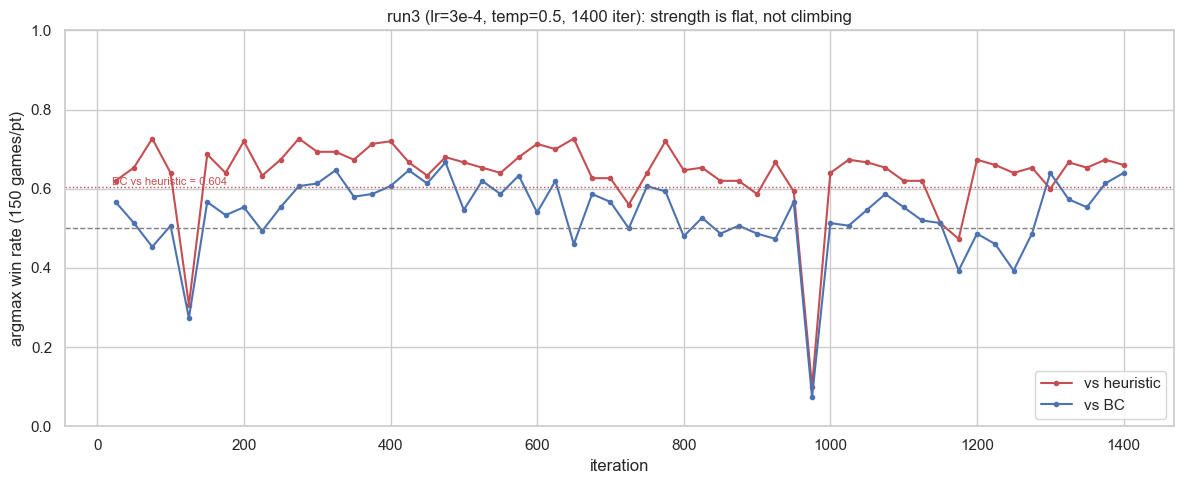

In [2]:
wr3 = eval_curve(RUNS["run3"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(wr3.index, wr3["heuristic"], marker=".", color="#c44e52", label="vs heuristic")
ax.plot(wr3.index, wr3["bc"], marker=".", color="#4c72b0", label="vs BC")
ax.axhline(0.5, ls="--", c="grey", lw=1)
ax.axhline(0.604, ls=":", c="#c44e52", lw=1)
ax.text(20, 0.61, "BC vs heuristic = 0.604", fontsize=8, color="#c44e52")
ax.set_xlabel("iteration")
ax.set_ylabel("argmax win rate (150 games/pt)")
ax.set_title("run3 (lr=3e-4, temp=0.5, 1400 iter): strength is flat, not climbing")
ax.set_ylim(0.0, 1.0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 2. Checkpoint-strength trend (clean N=300, vs heuristic)

Evaluating saved checkpoints across each run. **run1 oscillates** (peaks at
iter_25 = 0.71 then crashes to 0.61 — last-iterate is *not* best). **run2/run3
are stable** and the final net is the best — but they all sit in the same
~0.62-0.69 band. run3's 14x extra iterations (350 to 1400) add **nothing**.

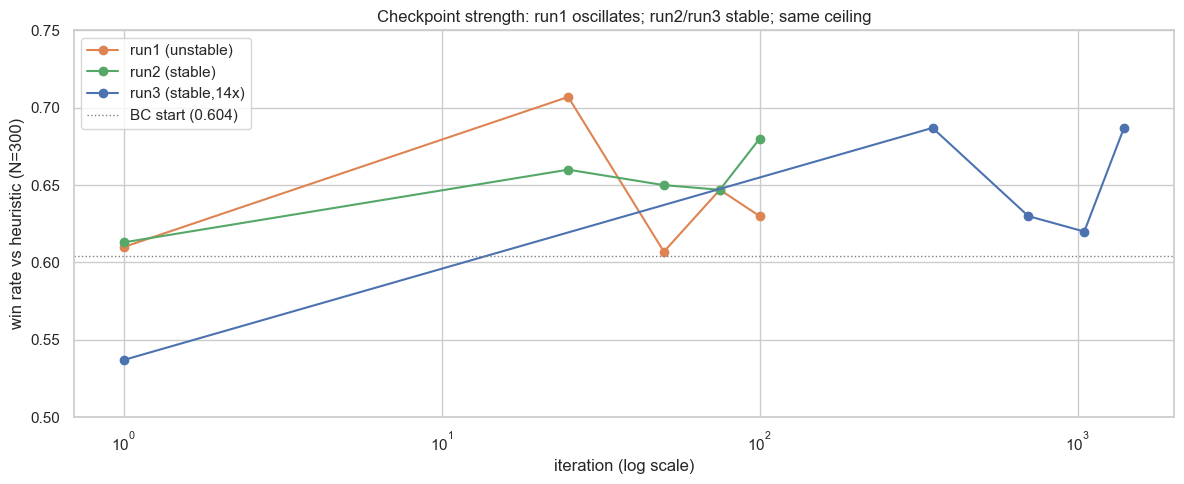

In [3]:
# Measured N=300 checkpoint evals vs heuristic (frozen results from run_eval).
TRENDS = {
    "run1 (unstable)":  {1: 0.610, 25: 0.707, 50: 0.607, 75: 0.647, 100: 0.630},
    "run2 (stable)":    {1: 0.613, 25: 0.660, 50: 0.650, 75: 0.647, 100: 0.680},
    "run3 (stable,14x)":{1: 0.537, 350: 0.687, 700: 0.630, 1050: 0.620, 1400: 0.687},
}
fig, ax = plt.subplots(figsize=(12, 5))
colors = {"run1 (unstable)": "#dd8452", "run2 (stable)": "#55a868",
          "run3 (stable,14x)": "#4c72b0"}
for name, pts in TRENDS.items():
    xs, ys = list(pts), list(pts.values())
    ax.plot(xs, ys, marker="o", label=name, color=colors[name])
ax.axhline(0.604, ls=":", c="grey", lw=1, label="BC start (0.604)")
ax.set_xscale("log")
ax.set_xlabel("iteration (log scale)")
ax.set_ylabel("win rate vs heuristic (N=300)")
ax.set_title("Checkpoint strength: run1 oscillates; run2/run3 stable; same ceiling")
ax.set_ylim(0.5, 0.75)
ax.legend()
plt.tight_layout()
plt.show()

## 3. The verdict — clean N=500 evals of the final checkpoints

`final.npz` is the last-iterate net OSFP submits. Head-to-head between runs is the
decisive test of "did the change help".

In [4]:
# Frozen N=500 results (run_eval, metal_aggro, argmax).
VERDICT = pd.DataFrame([
    {"comparison": "run1 final vs BC",        "winrate": 0.546, "ci": "[0.502, 0.589]",
     "read": "lean — barely > 0.5 (保留 band)"},
    {"comparison": "run2 final vs BC",        "winrate": 0.554, "ci": "[0.510, 0.597]",
     "read": "lean — same as run1"},
    {"comparison": "run3 final vs BC",        "winrate": 0.562, "ci": "[0.518, 0.605]",
     "read": "lean — same as run1/2"},
    {"comparison": "run2 final vs run1 final","winrate": 0.490, "ci": "[0.446, 0.534]",
     "read": "EQUAL — stabilising didn't raise strength"},
    {"comparison": "run3 final vs run2 final","winrate": 0.508, "ci": "[0.464, 0.552]",
     "read": "EQUAL — 14x data didn't raise strength"},
])
VERDICT

,comparison,winrate,ci,read
0,run1 final vs BC,0.546,"[0.502, 0.589]",lean — barely > 0.5 (保留 band)
1,run2 final vs BC,0.554,"[0.510, 0.597]",lean — same as run1
2,run3 final vs BC,0.562,"[0.518, 0.605]",lean — same as run1/2
3,run2 final vs run1 final,0.490,"[0.446, 0.534]",EQUAL — stabilising didn't raise strength
4,run3 final vs run2 final,0.508,"[0.464, 0.552]",EQUAL — 14x data didn't raise strength


## 4. Opponent pool growth (run3)

OSFP admits checkpoints (win-rate threshold or patience) into the recency-weighted
opponent pool. run3 grew to **482** checkpoints. Self-play iterations yield ~2-3x
the samples (both slots tagged `learner`).

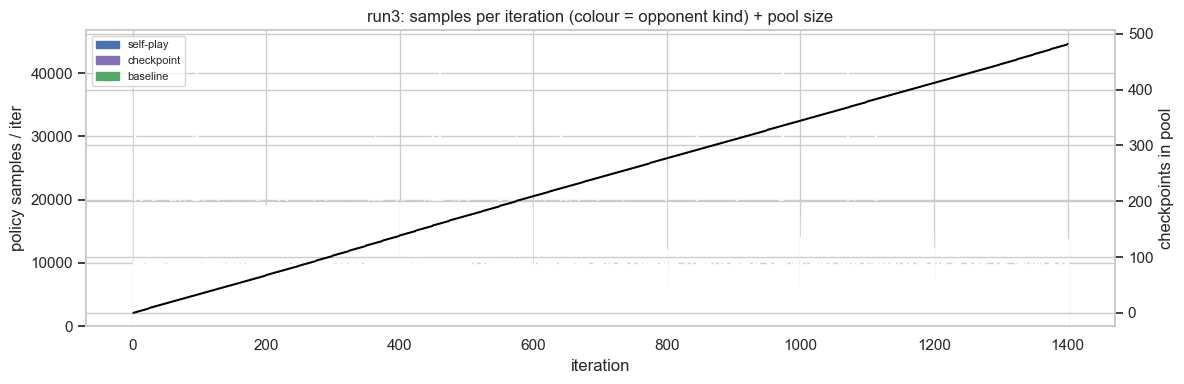

In [5]:
log3 = pd.DataFrame(RUNS["run3"]["iterations_log"])

def opp_kind(o):
    if o == "self":
        return "self-play"
    if o.endswith(".npz"):
        return "checkpoint"
    return "baseline"
log3["opp_kind"] = log3["opponent"].map(opp_kind)
log3["pool_size"] = log3["admitted"].cumsum()  # running count of admitted checkpoints
palette = {"self-play": "#4c72b0", "checkpoint": "#8172b3", "baseline": "#55a868"}

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(log3["iteration"], log3["n_samples"], width=1.0,
       color=log3["opp_kind"].map(palette))
ax.set_xlabel("iteration"); ax.set_ylabel("policy samples / iter")
ax.set_title("run3: samples per iteration (colour = opponent kind) + pool size")
ax2 = ax.twinx()
ax2.plot(log3["iteration"], log3["pool_size"], c="black", lw=1.4)
ax2.set_ylabel("checkpoints in pool")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in palette.values()]
ax.legend(handles, list(palette), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## Conclusion (Phase 5a)

- **It beats BC, modestly**: final nets reach **~0.56 vs BC** and **~0.68 vs
  heuristic** (BC was 0.604) — a real **~+8pp** but small gain. A valid, stable
  submission candidate.
- **Stabilising worked**: lowering lr (1e-3→3e-4) + temperature (1.0→0.5) removed
  run1's improve→collapse oscillation; the final checkpoint becomes reliably the
  best (last-iterate). But it did **not** raise strength (run2 ≈ run1).
- **Scale did NOT help**: 14x more data (run3, 1400 iter) is **statistically
  equal** to run2 (0.508), and strength plateaus by ~iter 350. **The bottleneck
  is capacity / representation, not data quantity.**
- Residual transient collapses persist (PPO-clip / V-Trace would address them, but
  that's a stability fix, not a ceiling-raiser).

**Next — Phase 5b (deck-head learning).** The project's central thesis is *deck
choice dominates Elo*. Phase 5a trained play on a **single fixed deck**; that lever
is now capped at ~+8pp. The bigger lever is the **deck itself** — learn the CB
(deck-construction) head with self-play returns (and a learned card embedding to
fix the CB's fixed-feature collapse). See `PLAN.md` Phase 5 / Phase 5c, 採否台帳.